#### Pre svega učitavamo module koji će nam biti potrebni

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from tqdm import trange

In [2]:
data_raw = fits.open('muram_snapshot_for_david.fits')
print("data shape =",data_raw[0].data.shape)

data shape = (5, 1024, 3, 70)


### Podaci koji su nam na raspolaganju su u formatu (5, 1024, 3, 70). 

### Raspolažemo sa 5 fizičkim veličinama u datoj atmosferi.

#### 1. Temperatura [K]
#### 2. Pritisak [dyne/$cm^2$]
#### 3. x-komponenta magnetnog polja $B_x$
#### 4. y-komponenta magnetnog polja $B_y$
#### 5. z-komponenta magnetnog polja $B_z$



### Za svaku fizičku veličinu imamo 3D 'kocku' sa geometrijskim osama u formatu (1024, 3, 70) (x,y,z).

### Prikazaćemo podatke za samo jedan y slice, tj. y osu nećemo koristiti. Takođe tokom celog notebook-a, magnetno polje nećemo koristiti.

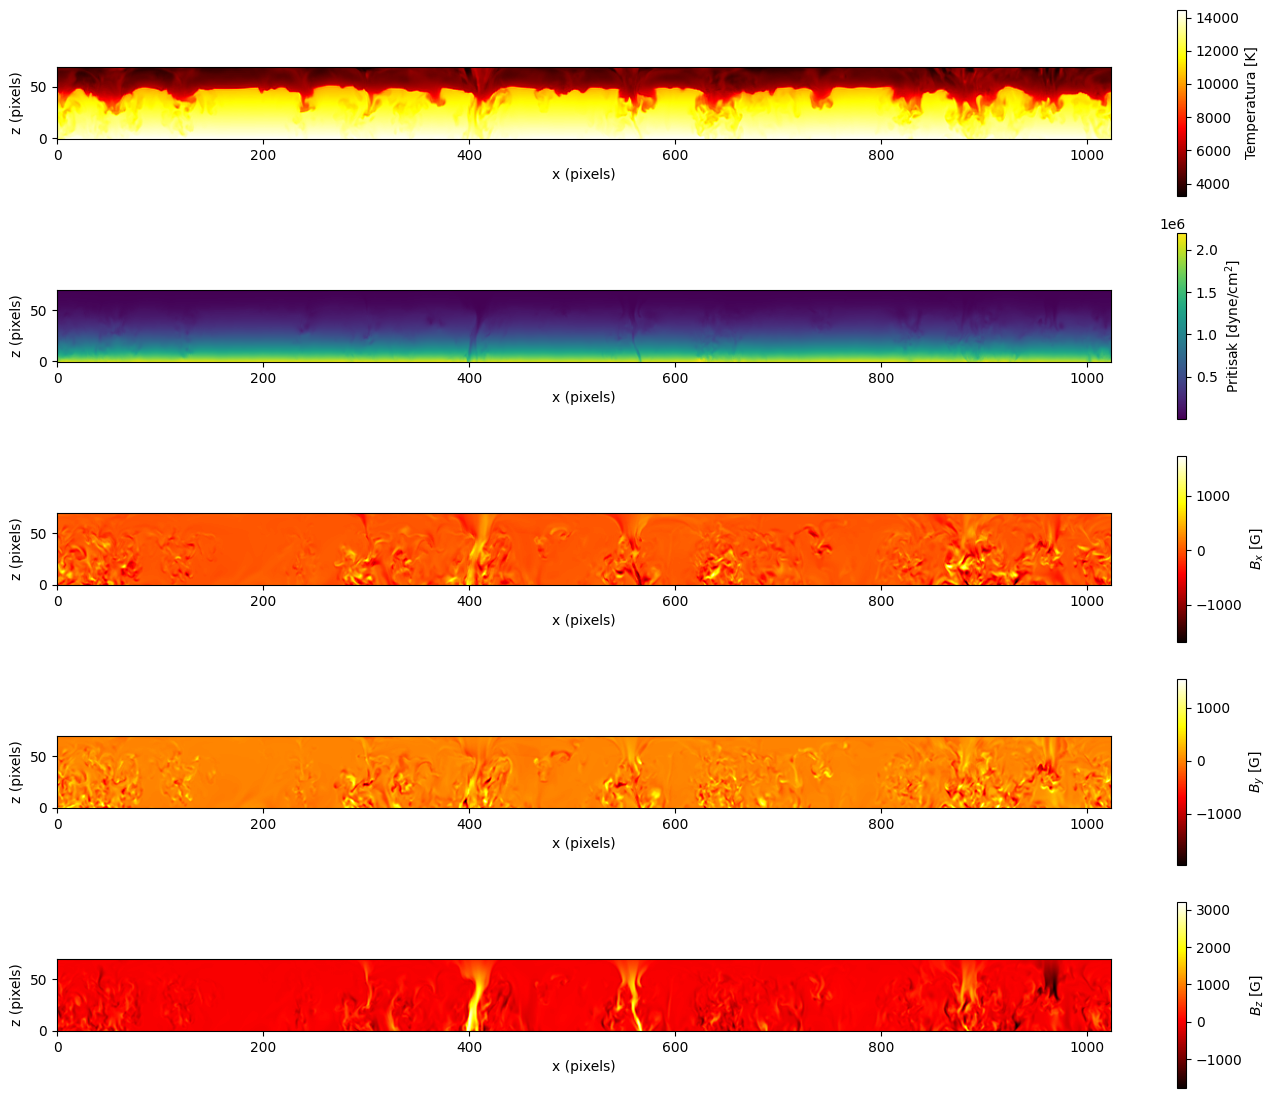

In [52]:
plt.figure(figsize=(17, 14))
plt.subplot(5, 1, 1)
plt.imshow(data_raw[0].data[0, :, 0, :].transpose(1,0), cmap='hot', origin='lower')
plt.xlabel('x (pixels)')
plt.ylabel('z (pixels)')
plt.colorbar(label = "Temperatura [K]")

plt.subplot(5, 1, 2)
plt.imshow(data_raw[0].data[1, :, 0, :].transpose(1,0), cmap='viridis', origin='lower')
plt.xlabel('x (pixels)')
plt.ylabel('z (pixels)')
plt.colorbar(label = "Pritisak [dyne/cm$^2$]")

plt.subplot(5, 1, 3)
plt.imshow(data_raw[0].data[2, :, 0, :].transpose(1,0), cmap='hot', origin='lower')
plt.xlabel('x (pixels)')
plt.ylabel('z (pixels)')
plt.colorbar(label = "$B_x$ [G]")

plt.subplot(5, 1, 4)
plt.imshow(data_raw[0].data[3, :, 0, :].transpose(1,0), cmap='hot', origin='lower')
plt.xlabel('x (pixels)')
plt.ylabel('z (pixels)')
plt.colorbar(label = "$B_y$ [G]")

plt.subplot(5, 1, 5)
plt.imshow(data_raw[0].data[4, :, 0, :].transpose(1,0), cmap='hot', origin='lower')
plt.xlabel('x (pixels)')
plt.ylabel('z (pixels)')
plt.colorbar(label = "$B_z$ [G]")


### Hajdemo prvo da se fokusiramo samo na 1D problem. Uzećemo isecak atmosfere samo po z osi.

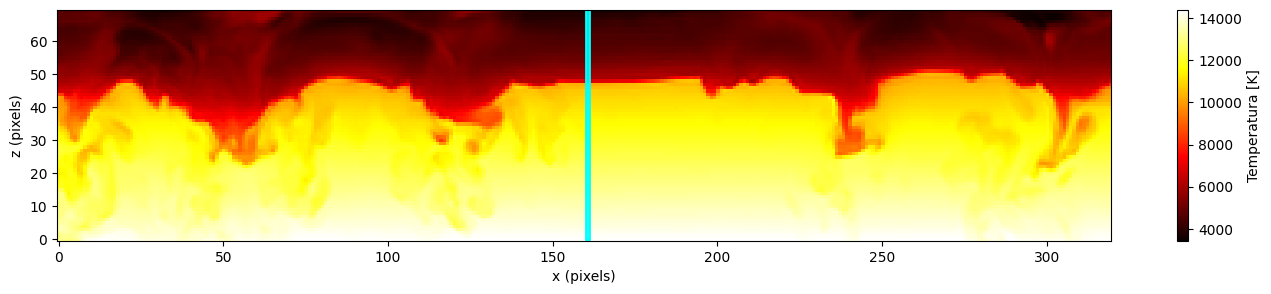

In [4]:
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(17, 3))

im = ax.imshow(
    data_raw[0].data[0, 0:320, 0, :].transpose(1, 0),
    cmap='hot',
    origin='lower'
)

ax.set_xlabel('x (pixels)')
ax.set_ylabel('z (pixels)')
plt.colorbar(im, ax=ax, label="Temperatura [K]")

# Rectangle: x from 160 to 170, z from 50 to 60
rect = patches.Rectangle(
    (160, 0),   # (x_min, z_min)
    1,          # width = 170 - 160
    70,          # height = 60 - 50
    linewidth=2,
    edgecolor='cyan',
    facecolor='none'
)

ax.add_patch(rect)

plt.show()

In [5]:
data_1D = data_raw[0].data[:, 160, 0, :] # Ovime smo uklonili x i y osu, ostale su nam samo fizičke veličine koje zavise od z

print("data_1D shape =",data_1D.shape)

data_1D shape = (5, 70)


In [6]:
T_1D = data_1D[0] # Podaci 1D Temperature
P_1D = data_1D[1] # Podaci 1D Pritiska
   
z_min = 0         # metri
z_max = 70 * 24e3 # metri
z_sim = np.linspace(z_min, z_max, len(T_1D))

Text(0, 0.5, 'Pritisak (dyne/cm$^2$)')

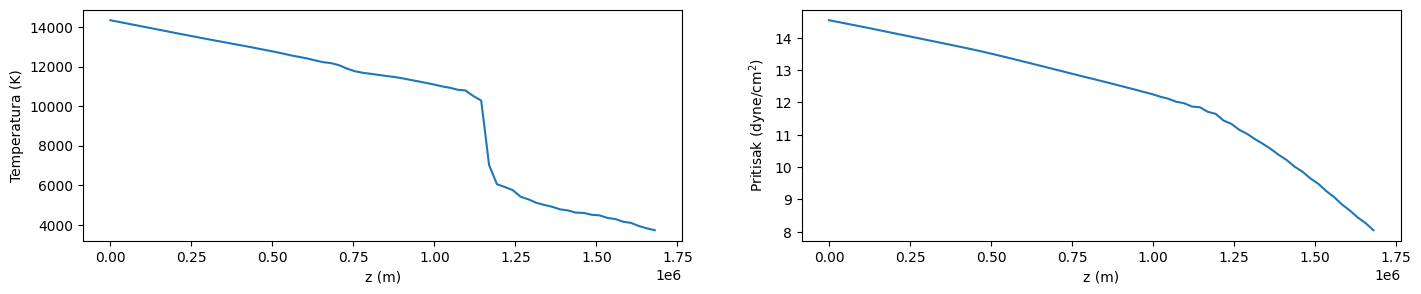

In [7]:
plt.figure(figsize=(17, 3))
plt.subplot(1, 2, 1)
plt.plot(z_sim, T_1D)
plt.xlabel("z (m)")
plt.ylabel("Temperatura (K)")

plt.subplot(1, 2, 2)
plt.plot(z_sim, np.log(P_1D))
plt.xlabel("z (m)")
plt.ylabel("Pritisak (dyne/cm$^2$)")  

Razmatra se 1D sistem u hidrostatickoj ravnoteži, opisan jednačinom
\begin{equation}
\frac{dP}{dz} = -\rho g ,
\notag
\end{equation}
gde je $P(z)$ pritisak, $\rho(z)$ gustina, a $g$ gravitaciono ubrzanje.

Pritisak i gustina povezuju se jednačinom idealnog gasa
\begin{equation}
P = \rho \frac{k_B T}{\mu m_p},
\notag
\end{equation}
gde je $T(z)$ temperatura, $k_B$ Bolcmanova konstanta, $m_p$ masa protona, a $\mu$ srednja molekulska masa.

\begin{equation}
H = \frac{k_B T}{\mu m_p} ,
\notag
\end{equation}

\begin{equation}
P = \rho \cdot H \Rightarrow \rho = \frac{P}{H(T)}
\notag
\end{equation}

Zamenom jednačine idealnog gasa u jednačinu hidrostaticke ravnoteže dobija se diferencijalna jednačina u kojoj eksplicitno zavisi temperatura:
\begin{equation}
\frac{dP}{dz} = -\frac{P}{H(T)},
\notag
\end{equation}

\begin{equation}
\frac{dlogP}{dz} = - \frac{1}{H(T)}
\notag
\end{equation}

Celu jednačinu ćemo sada pomnožiti sa $z_{max}$, kako bismo dobili bezdimenzioni oblik ove jednačine:

\begin{equation}
\frac{dlogP}{z} \cdot z_{max} = - \frac{1}{H(T)} \cdot z_{max},
\notag
\end{equation}

Sledi,

\begin{equation}
\frac{dlogP}{d\frac{z}{z_{max}}} = - \frac{z_{max}}{H(T)},
\notag
\end{equation}

U ovakvom formatu ćemo mi koristiti jednačinu hidrostatičke ravnoteže.

In [8]:
# Fizičke konstante

m_sr = 1 * 1.66053906660e-27      # kg
k_b = 1.380649e-23                # J/K
g = 274.0                         # gravitaciono ubrzanje na Suncu - m/s^2


#### U sledećem koraku formiramo ulazne promenljive za PINN i prilagođavamo ih tako da budu pogodne za automatsku diferencijaciju i stabilno treniranje mreže.

#### Koordinata visine z se najpre normalizuje deljenjem sa maksimalnom visinom domena zmax⁡. Normalizacija je važna jer neuronske mreže mnogo stabilnije uče kada su ulazi reda veličine $O(1)$, a ujedno se izbegavaju numerički problemi prilikom računanja gradijenata.

#### Nakon normalizacije, podaci se prebacuju u PyTorch tensor i oblikuju u kolonu dimenzije (N,1), što odgovara formatu ulaza neuronske mreže.

In [9]:
# Priprema podataka za treniranje PINN-a

Z_flat = torch.from_numpy(z_sim / z_max).float().reshape(-1, 1)
Z_dom = Z_flat.requires_grad_(True)
print("Z_dom:", Z_dom.shape)

Z_top = torch.ones(1, 1)   # z = z_max / normalizovano na 1


Z_dom: torch.Size([70, 1])


#### U ovom koraku definišemo neuronsku mrežu koja predstavlja aproksimaciju nepoznatih fizičkih veličina u Physics-Informed Neural Network (PINN) pristupu. Mreža uči mapiranje između prostorne koordinate z i izlaznih fizičkih polja, pri čemu se fizička ograničenja nameću preko funkcije gubitka.

In [10]:
# Definicija PINN mreže

class PINN(nn.Module):

    def __init__(self):
        super().__init__()
        layers = []
        sizes = [1] + [32] + [64] + [64] + [64] + [32] + [2]
        for i in range(len(sizes) - 1):                    # za svaki sloj
            layers.append(nn.Linear(sizes[i], sizes[i+1])) # linearna transformacija
            if i < len(sizes) - 2:                         # dodajem aktivaciju osim za izlazni sloj
                layers.append(nn.Tanh())
                
        self.net = nn.Sequential(*layers) 
        # Sequential kombinuje module u lanac

        for m in self.net:               # uzima svaki modul iz sekvencijalnog modela
            if isinstance(m, nn.Linear): # samo linerarni slojevi imaju tezine i bias
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, X):
        return self.net(X)

#### Nakon definicije arhitekture neuronske mreže, instanciramo PINN model i biramo algoritam za optimizaciju njegovih parametara.

#### Za optimizaciju se koristi Adam optimizator, koji predstavlja adaptivnu varijantu stohastičkog gradijentnog spusta. Adam automatski prilagođava efektivnu brzinu učenja za svaki parametar na osnovu prvog i drugog momenta gradijenata, što ga čini posebno pogodnim za treniranje dubokih neuronskih mreža i PINN modela.

#### Izabrana brzina učenja (lr = 10^{-5}) je relativno mala, što je čest izbor kod PINN-ova. Razlog je to što funkcija gubitka sadrži više komponenti (PDE reziduali, granični uslovi i podaci), kao i gradijente višeg reda, pa manja brzina učenja doprinosi stabilnijoj konvergenciji i smanjuje rizik od oscilacija tokom treniranja.

In [11]:
model = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

#### U ovom koraku pripremamo fizičke podatke koji se koriste za definisanje graničnih uslova, normalizaciju izlaza neuronske mreže i stabilno formulisanje funkcije gubitka u PINN modelu.

In [12]:
################################################################################################
# Ova vrednost se koristi za nametanje graničnog uslova na vrhu domena.
P_top = P_1D[-1] 
P_top_torch = torch.from_numpy(np.ascontiguousarray(P_top).astype(np.float32)).to(Z_dom.device)
logP_top_torch = torch.log(P_top_torch)

################################################################################################
# Za potrebe normalizacije izlaza neuronske mreže, određuje se maksimalna vrednost pritiska u domenu. 
# Maksimalni pritisak služi kao referentna skala, tako da neuronska mreža uči redukovanu veličinu
P_sim_torch = torch.from_numpy(np.ascontiguousarray(P_1D).astype(np.float32)).to(Z_dom.device)
P_max = torch.max(P_sim_torch)
logP_max = torch.log(P_max)

################################################################################################
# Na sličan način se priprema temperaturni profil. 
# Maksimalna temperatura u domenu koristi se kao normalizaciona konstanta.
T_max = np.max(T_1D)
T_sim = torch.from_numpy(np.ascontiguousarray(T_1D).astype(np.float32)).reshape(-1, 1).to(Z_dom.device)

#### U ovom koraku definišemo funkciju gubitka Physics-Informed Neural Network (PINN) modela. Ukupan gubitak se sastoji iz tri komponente: reziduala parcijalne diferencijalne jednačine (PDE), uslova saglasnosti sa temperaturnim podacima i graničnog uslova na vrhu domena.

Ukupna funkcija gubitka definiše se kao zbir doprinosa iz unutrašnjosti domena i graničnih uslova:
\begin{equation}
\mathcal{L} = \mathcal{L}_{\mathrm{PDE}} + \mathcal{L}_{\mathrm{data}} + \mathcal{L}_{\mathrm{BC}} ,
\notag
\end{equation}

Gubitak na podacima forsira slaganje predikcije neuronske mreže sa poznatim temperaturnim profilom i definiše se kao
\begin{equation}
\mathcal{L}_{\mathrm{data}} =
\left\| T_{\mathrm{NN}}(z) - T_{\mathrm{data}}(z) \right\|^2 ,
\notag
\end{equation}
čime se osigurava da neuronska mreža reprodukuje dostupne temperaturne podatke duž celog domena.

PDE gubitak nameće uslov hidrostatčke ravnoteže na predviđeni pritisak. U logaritamskom zapisu, hidrostatčka jednačina ima oblik
\begin{equation}
\frac{d \log P}{dz} + \frac{\mu m_p}{k_B T} = 0 ,
\notag
\end{equation}
pa se odgovarajući rezidual u PINN okviru definiše kao

\begin{equation}
\mathcal{L}_{\mathrm{PDE}} =\left\|\frac{d \log P_{\mathrm{NN}}}{dz}+ \frac{\mu m_p}{k_B T_{\mathrm{data}}}\right\|^2 .
\notag
\end{equation}

Dodatno, poznata vrednost pritiska na gornjoj granici domena uvodi se kroz poseban granični gubitak
\begin{equation}
\mathcal{L}_{\mathrm{BC}} =
\left\|
\log P_{\mathrm{NN}}(z_{\max}) - \log P_{\mathrm{top}}
\right\|^2 ,
\notag
\end{equation}
čime se obezbeđuje da rešenje neuronske mreže zadovoljava granični uslov nezavisno od ponašanja u unutrašnjosti domena.

#### Na ovaj način, minimizacijom ukupne funkcije gubitka neuronska mreža istovremeno uči da reprodukuje poznati temperaturni profil, zadovolji jednačinu hidrostatčke ravnoteže i ispuni zadati granični uslov za pritisak.


In [13]:

def pinn_loss():

    # NN output
    Y = model(Z_dom)
    logp_reduced = Y[:, 0:1]              
    logp = logp_reduced + logP_max

    T_reduced = Y[:, 1:2]
    T = T_reduced * T_max

    grads = torch.autograd.grad(
        logp, Z_dom,
        grad_outputs=torch.ones_like(logp),
        create_graph=True
    )[0]

    dlogp_dz = grads[:, 0:1]

    # --------------------
    # Skala visine u normalizovanom obliku
    # --------------------
    H = (k_b * T_sim) / (m_sr * g)         # u metrima
    H_norm = H / z_max                     # normalizovano

    # --------------------
    # PDE rezidual u normalizovanom obliku 
    # --------------------
    Rez_1 = dlogp_dz + 1 / H_norm

    # --------------------
    # Temperaturni rezidual
    # --------------------
    Rez_3 = (T - T_sim) / T_max

    # --------------------
    # Granični uslov (VRH DOMENA)
    # --------------------
    logP_top_pred = model(Z_top)[:, 0:1]
    Rez_bc = (logP_top_pred + logP_max) - logP_top_torch

    # --------------------
    # Gubici skalarni
    # --------------------
    L_pde_1 = 1 * Rez_1.pow(2).mean()
    L_3 = 1 * Rez_3.pow(2).mean()
    L_bc  = 1 * Rez_bc.pow(2).mean()

    total_loss = L_pde_1 + L_bc + L_3

    return total_loss, L_pde_1, L_bc, L_3


#### U ovom delu se vrši treniranje neuronske mreže. Tokom svakog epoha računa se ukupni gubitak PINN modela i prilagođavaju se težine mreže kako bi mreža istovremeno zadovoljila PDE rezidual, temperaturne podatke i granični uslov.

In [14]:
history = {
    "epoch": [],
    "loss_total": [],
    "loss_dlogp_dz": [],
    "loss_T": [],
    "bc_p": [],
}
#  desc="Training"
for epoch in trange(40000):
    optimizer.zero_grad()

    loss, L1, L2, L3 = pinn_loss()
    loss.backward()
    optimizer.step()
    
    history["loss_total"].append(loss.item())

    if epoch % 10000 == 0:
        history["epoch"].append(epoch)
        history["loss_dlogp_dz"].append(L1.item())
        history["loss_T"].append(L2.item())
        history["bc_p"].append(L3.item())
    
        print(f"\nEpoch {epoch}")
        print(f"  total loss   : {loss.item():.3e}")
        print(f"  dlogp/dz     : {L1.item():.3e}")
        print(f"  T loss       : {L2.item():.3e}")
        print(f"  BC logp      : {L3.item():.3e}")

  0%|          | 54/40000 [00:00<02:28, 269.06it/s]


Epoch 0
  total loss   : 9.407e+01
  dlogp/dz     : 5.454e+01
  T loss       : 3.876e+01
  BC logp      : 7.701e-01


 25%|██▌       | 10030/40000 [00:44<02:37, 190.12it/s]


Epoch 10000
  total loss   : 1.398e-01
  dlogp/dz     : 1.203e-01
  T loss       : 6.822e-03
  BC logp      : 1.269e-02


 50%|█████     | 20039/40000 [01:44<01:37, 205.07it/s]


Epoch 20000
  total loss   : 6.925e-03
  dlogp/dz     : 6.024e-03
  T loss       : 3.882e-06
  BC logp      : 8.973e-04


 75%|███████▌  | 30036/40000 [02:41<00:51, 195.05it/s]


Epoch 30000
  total loss   : 9.623e-04
  dlogp/dz     : 8.075e-04
  T loss       : 2.506e-08
  BC logp      : 1.548e-04


100%|██████████| 40000/40000 [03:36<00:00, 185.13it/s]


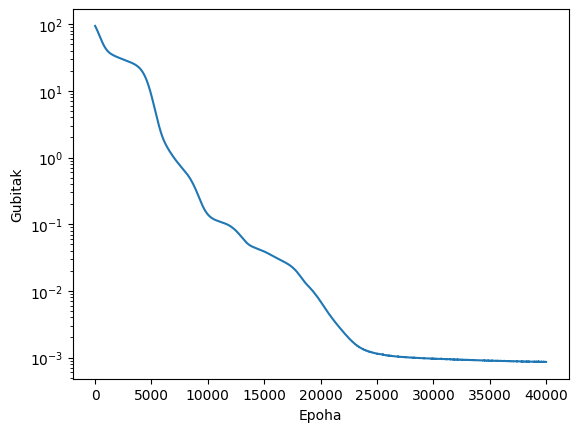

In [15]:
plt.semilogy(history["loss_total"])
plt.xlabel("Epoha")
plt.ylabel("Gubitak")
plt.show()

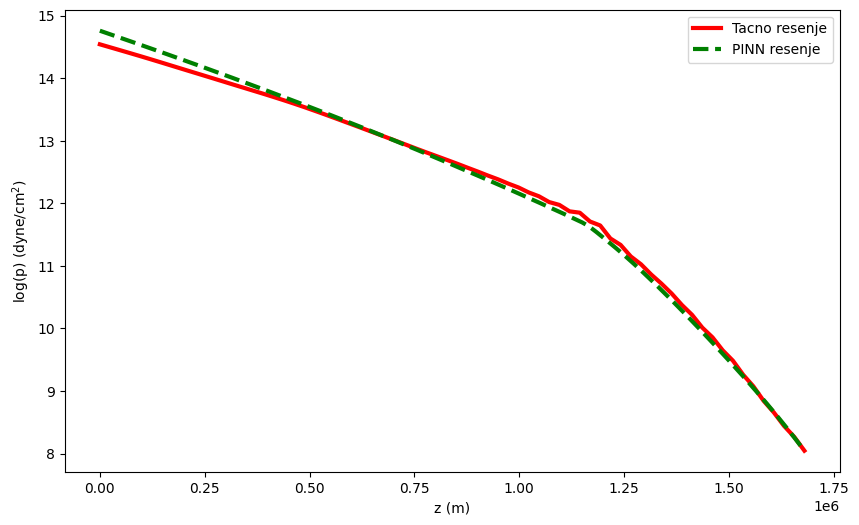

In [23]:
z_re = np.linspace(z_min, z_max, 150)
Z_re = torch.from_numpy(z_re / z_max).float().reshape(-1, 1).to(Z_dom.device)

p_pred = model(Z_re)[:,0] + logP_max
p_pred = p_pred.detach().numpy() # predikcija mreze

plt.figure(figsize = (10,6)) 
plt.plot(z_sim, np.log(P_1D), "red", label = "Tacno resenje", linewidth=3)
plt.plot(z_re, p_pred, "g--", label = "PINN resenje", linewidth=3)
plt.xlabel("z (m)")
plt.ylabel("log(p) (dyne/cm$^2$)")
plt.legend()
plt.show()


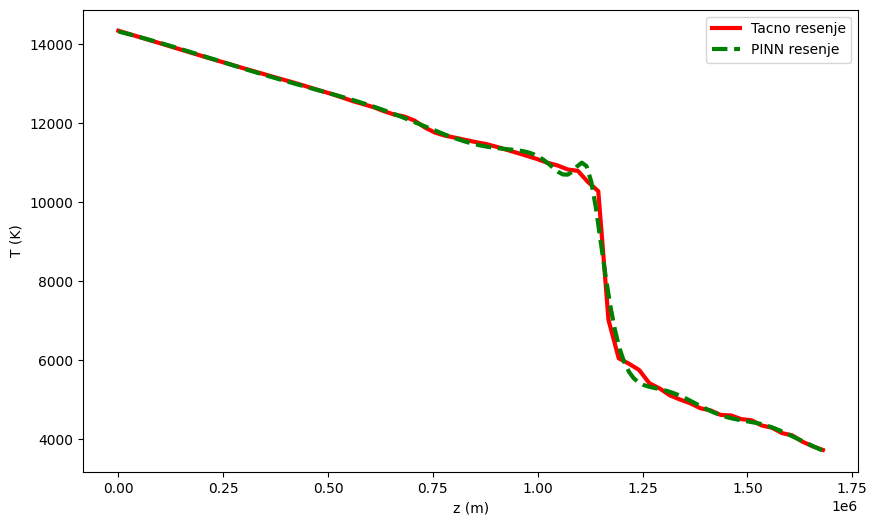

In [26]:
T_pred = model(Z_re)[:,1] * T_max
T_pred = T_pred.detach().numpy() # predikcija mreze

plt.figure(figsize = (10,6)) 
plt.plot(z_sim, T_1D, "red", label = "Tacno resenje", linewidth=3)
plt.plot(z_re, T_pred, "g--", label = "PINN resenje", linewidth=3)
plt.xlabel("z (m)")
plt.ylabel("T (K)")
plt.legend()
plt.show()


# Sada cemo uključiti i x-osu tj. radićemo na 2D problemu.

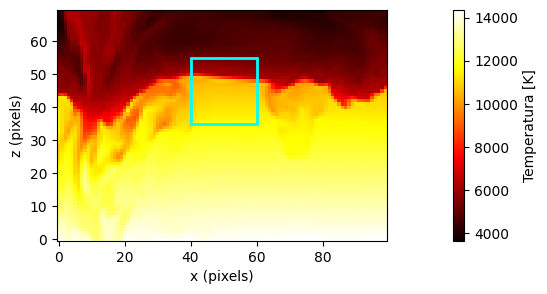

In [28]:
fig, ax = plt.subplots(figsize=(17, 3))

im = ax.imshow(
    data_raw[0].data[0, 400:500, 0, :].transpose(1, 0),
    cmap='hot',
    origin='lower'
)

ax.set_xlabel('x (pixels)')
ax.set_ylabel('z (pixels)')
plt.colorbar(im, ax=ax, label="Temperatura [K]")


rect = patches.Rectangle(
    (40, 35),   # (x_min, z_min)
    20,          # width = 170 - 160
    20,          # height = 60 - 50
    linewidth=2,
    edgecolor='cyan',
    facecolor='none'
)

ax.add_patch(rect)

plt.show()

In [29]:
# Ovime smo uklonili x i y osu, ostale su nam samo fizičke veličine koje zavise od z
data_2D = data_raw[0].data[:, 440:460, 0, 35:55] 
    
print("data_2D shape =",data_2D.shape)  

data_2D shape = (5, 20, 20)


In [32]:
T_2D = data_2D[0, :, :]
P_2D = data_2D[1, :, :]

print("Pritisak i temperatura su dimenzija:", np.shape(T_2D))

Pritisak i temperatura su dimenzija: (20, 20)


### Radimo sa sledećim podacima:

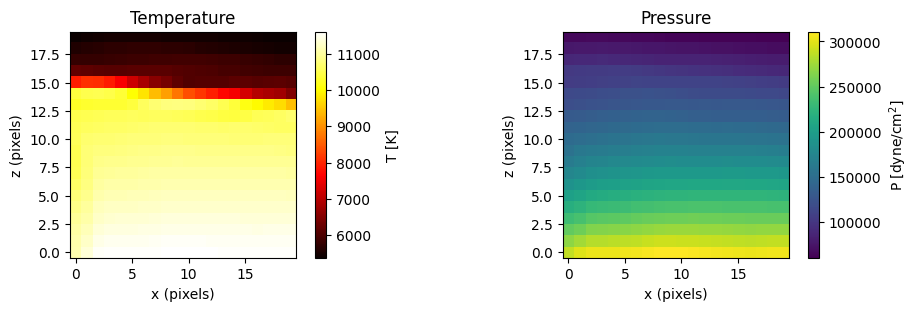

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3), constrained_layout=True)
# --- Temperature ---
im0 = ax[0].imshow(T_2D.transpose(1, 0),cmap='hot',origin='lower', aspect = 1)
ax[0].set_title('Temperature')
ax[0].set_xlabel('x (pixels)')
ax[0].set_ylabel('z (pixels)')
fig.colorbar(im0, ax=ax[0], label='T [K]')

# --- Pressure ---
im1 = ax[1].imshow(P_2D.transpose(1, 0),cmap='viridis',origin='lower', aspect=1)
ax[1].set_title('Pressure')
ax[1].set_xlabel('x (pixels)')
ax[1].set_ylabel('z (pixels)')
fig.colorbar(im1, ax=ax[1], label='P [dyne/cm$^2$]')

plt.show()


#### Jedino što je drugačije ovde, naspram prethodnog primera jeste da sada imamo dva ulaza, s obzirom da radimo na 2D podacima.

In [34]:
# We define the NN:

class PINN(nn.Module):

    def __init__(self):
        super().__init__()
        layers = []
        sizes = [2] + [32] + [64] + [128] * 2 + [64] + [32] + [2]
        for i in range(len(sizes) - 1): # za svaki sloj
            layers.append(nn.Linear(sizes[i], sizes[i+1])) # linearna transformacija
            if i < len(sizes) - 2: # dodajem aktivaciju osim za izlazni sloj
                layers.append(nn.Tanh())
                
        self.net = nn.Sequential(*layers) # zvezdica da se razbije lista u argumente
        # Sequential kombinuje module u lanac

        for m in self.net: # uzima svaki modul iz sekvencijalnog modela
            if isinstance(m, nn.Linear): # samo linerarni slojevi imaju tezine i bias
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, X):
        return self.net(X)

In [40]:
N_x = len(T_2D[: , 0]) # broj piksela u x
N_z = len(T_2D[0 , :]) # broj piksela u z

# Fizičke konstante
dx, dz = 24e3, 24e3  # fizicka vrednost piksela u metrima
m_sr = 1.15 * 1.66053906660e-27   # kg
k_b = 1.380649e-23                # J/K
g = 274.0                         # m/s^2
z_max = N_z * dz                  # m
x_max = N_x * dx                  # m

#### Formiramo podatke za treniranje

In [41]:
x_sim = np.linspace(0, N_x, N_x) * dx
z_sim = np.linspace(0, N_z, N_z) * dz
X, Z = np.meshgrid(x_sim, z_sim, indexing="ij")  # (N_x, N_z)

X_flat = torch.from_numpy(X / x_max).float().reshape(-1, 1)
Z_flat = torch.from_numpy(Z / z_max).float().reshape(-1, 1)  
X_dom = torch.cat([X_flat, Z_flat], dim=1).requires_grad_(True)

# Vrh domena (z = z_max)
x_top = torch.from_numpy(X[:, -1] / x_max).float().unsqueeze(1)
z_top = torch.ones_like(x_top)
X_top = torch.cat([x_top, z_top], dim=1)

print("X_dom:", X_dom.shape)
print("X_top:", X_top.shape)

X_dom: torch.Size([400, 2])
X_top: torch.Size([20, 2])


In [42]:
model = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

In [43]:
################################################################################################
# Ova vrednost se koristi za nametanje graničnog uslova na vrhu domena.
P_top = P_2D[: , -1] 
P_top_torch = torch.from_numpy(np.ascontiguousarray(P_top).astype(np.float32)).to(X_dom.device)
logP_top_torch = torch.log(P_top_torch)

################################################################################################
# Za potrebe normalizacije izlaza neuronske mreže, određuje se maksimalna vrednost pritiska u domenu. 
# Maksimalni pritisak služi kao referentna skala, tako da neuronska mreža uči redukovanu veličinu
P_sim_torch = torch.from_numpy(np.ascontiguousarray(P_2D).astype(np.float32)).to(X_dom.device)
P_max = torch.max(P_sim_torch)   
logP_max = torch.log(P_max)

################################################################################################
# Na sličan način se priprema temperaturni profil. 
# Maksimalna temperatura u domenu koristi se kao normalizaciona konstanta.
T_max = np.max(T_2D)
T_sim_flat = torch.from_numpy(np.ascontiguousarray(T_2D).astype(np.float32)).reshape(-1, 1).to(X_dom.device)

In [44]:
def pinn_loss():

    # NN output
    Y = model(X_dom)
    logp_reduced = Y[:, 0:1]
    logp = logp_reduced + logP_max

    T_reduced = Y[:, 1:2]
    T = T_reduced * T_max

    grad = torch.autograd.grad(
        logp, X_dom,
        grad_outputs=torch.ones_like(logp),
        create_graph=True,
    )[0]

    dlogp_dz = grad[:, 1:2]

    # --------------------
    # Skala visine u normalizovanom obliku
    # --------------------
    H = (k_b * T_sim_flat) / (m_sr * g)         # u metrima
    H_norm = H / z_max  

    # --------------------
    # PDE rezidual u normalizovanom obliku 
    # --------------------
    Rez_1 = dlogp_dz + 1 / H_norm

    # --------------------
    # Temperaturni rezidual
    # --------------------
    Rez_3 = (T - T_sim_flat) / T_max

    # --------------------
    # Granični uslov (VRH DOMENA)
    # --------------------

    logP_top_pred = model(X_top)[:, 0:1]  # NN output = log(P/P0)
    Rez_bc = (logP_top_pred + logP_max) - logP_top_torch

    # --------------------
    # Skalarni gubici
    # --------------------
    L_pde_1 = 1 * Rez_1.pow(2).mean()
    L_3 = 1 * Rez_3.pow(2).mean()
    L_bc  = 1 * Rez_bc.pow(2).mean()



    total_loss = L_pde_1 + L_bc + L_3

    return total_loss, L_pde_1, L_bc, L_3

#### Treniranje mreže.

In [45]:
history = {
    "epoch": [],
    "loss_total": [],
    "loss_dlogp_dz": [],
    "loss_T": [],
    "bc_p": [],
}
#  desc="Training"
for epoch in trange(50000):
    optimizer.zero_grad()

    loss, L1, L3, L4 = pinn_loss()
    loss.backward()
    optimizer.step()
    
    history["loss_total"].append(loss.item())

    if epoch % 10000 == 0:
        history["epoch"].append(epoch)
        history["loss_dlogp_dz"].append(L1.item())
        history["loss_T"].append(L3.item())
        history["bc_p"].append(L4.item())
    
        print(f"\nEpoch {epoch}")
        print(f"  total loss   : {loss.item():.3e}")
        print(f"  dlogp/dz     : {L1.item():.3e}")
        print(f"  T loss       : {L3.item():.3e}")
        print(f"  BC logp      : {L4.item():.3e}")

  0%|          | 11/50000 [00:00<09:04, 91.85it/s]


Epoch 0
  total loss   : 7.242e+00
  dlogp/dz     : 4.309e+00
  T loss       : 2.480e+00
  BC logp      : 4.529e-01


 20%|██        | 10018/50000 [01:23<07:09, 92.99it/s]


Epoch 10000
  total loss   : 6.723e-03
  dlogp/dz     : 3.422e-03
  T loss       : 1.018e-03
  BC logp      : 2.284e-03


 40%|████      | 20011/50000 [03:04<05:04, 98.63it/s] 

...

 60%|██████    | 30030/50000 [04:33<02:15, 147.86it/s]


Epoch 30000
  total loss   : 1.097e-03
  dlogp/dz     : 4.515e-05
  T loss       : 1.017e-03
  BC logp      : 3.463e-05


 80%|████████  | 40019/50000 [06:01<02:12, 75.10it/s] 


Epoch 40000
  total loss   : 1.086e-03
  dlogp/dz     : 3.819e-05
  T loss       : 1.016e-03
  BC logp      : 3.176e-05


100%|██████████| 50000/50000 [07:40<00:00, 108.47it/s]


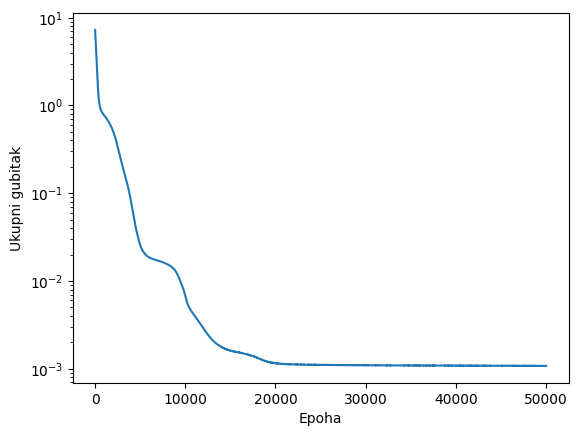

In [53]:
plt.semilogy(history["loss_total"])
plt.xlabel("Epoha")
plt.ylabel("Ukupni gubitak")
plt.show()

Text(0.5, 1.0, 'Rel_err = (T_pred - T_sim) / T_sim')

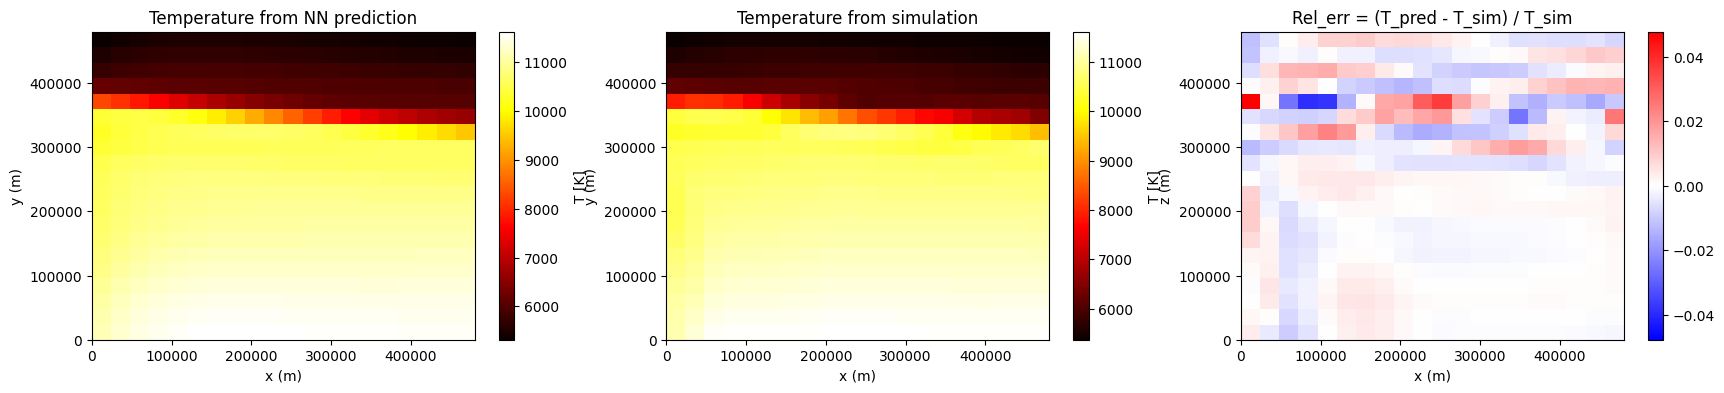

In [48]:
T_pred = model(X_dom)[:,1] * T_max
T_pred = T_pred.detach().numpy().reshape(N_x, N_z) # predikcija mreze

rel_err = (T_pred - T_2D) / T_2D

vmax_err = np.max(np.abs(rel_err))

fig, ax = plt.subplots(1, 3, figsize = (21,4))
ax[0].imshow(T_pred.transpose(1,0), label = "NN prediction")
fig.colorbar(ax[0].imshow(T_pred.transpose(1,0), extent=[0, x_max, 0, z_max], aspect='auto', origin='lower', cmap='hot'), label = "T [K]")
ax[0].set_title('Temperature from NN prediction')
ax[0].set_xlabel('x (m)')
ax[0].set_ylabel('y (m)')

ax[1].imshow(T_2D.transpose(1,0))
fig.colorbar(ax[1].imshow(T_2D.transpose(1,0), extent=[0, x_max, 0, z_max], aspect='auto', origin='lower', cmap='hot'), label = "T [K]")
ax[1].set_title('Temperature from simulation')
ax[1].set_xlabel('x (m)')
ax[1].set_ylabel('y (m)')

ax[2].imshow(rel_err.T,vmin=-vmax_err,vmax= vmax_err)
ax[2].set_xlabel('x (m)')
ax[2].set_ylabel('z (m)')
fig.colorbar(ax[2].imshow(rel_err.T, extent=[0, x_max, 0, z_max], vmin=-vmax_err, vmax= vmax_err, aspect='auto', origin='lower', cmap='bwr'))
ax[2].set_title('Rel_err = (T_pred - T_sim) / T_sim')

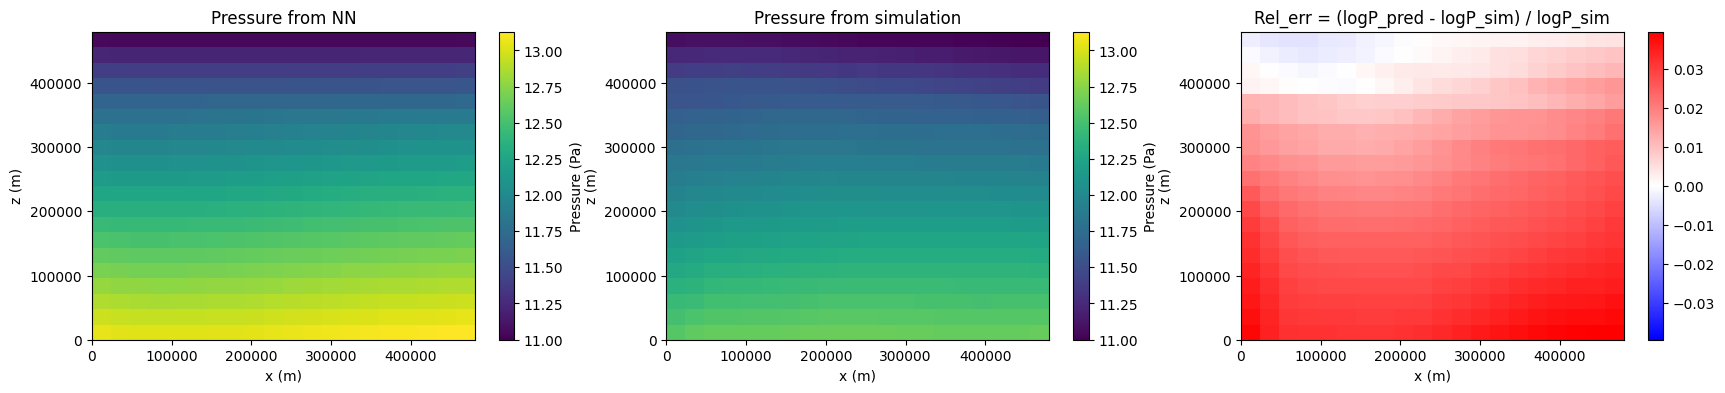

In [49]:
logP_pred_all = model(X_dom)[:,0] + logP_max
logP_pred_all = logP_pred_all.detach().numpy().reshape(N_x, N_z) # predikcija mreze

vmin = min(np.min(logP_pred_all), np.min(np.log(P_2D)))
vmax = max(np.max(logP_pred_all), np.max(np.log(P_2D)))

rel_err = (logP_pred_all - np.log(P_2D)) / np.log(P_2D)
vmax_err = np.max(np.abs(rel_err))


fig, ax = plt.subplots(1, 3, figsize=(21,4))
ax[0].imshow(logP_pred_all.transpose(1,0))
ax[0].set_xlabel('x (m)')
ax[0].set_ylabel('z (m)')
fig.colorbar(ax[0].imshow(logP_pred_all.transpose(1,0), extent=[0, x_max, 0, z_max],vmin=vmin, vmax=vmax, aspect='auto', origin='lower', cmap='viridis'), label='Pressure (Pa)')
ax[0].set_title('Pressure from NN')

ax[1].imshow(np.log(P_2D), vmin = vmin, vmax = vmax)
ax[1].set_xlabel('x (m)')
ax[1].set_ylabel('z (m)')
fig.colorbar(ax[1].imshow(np.log(P_2D).transpose(1,0), extent=[0, x_max, 0, z_max],vmin=vmin, vmax=vmax, aspect='auto', origin='lower', cmap='viridis'), label='Pressure (Pa)')
ax[1].set_title('Pressure from simulation')
#plt.suptitle('Pressure Comparison: PINN Prediction vs Simulation')

ax[2].imshow(rel_err.T,vmin=-vmax_err,vmax= vmax_err)
ax[2].set_xlabel('x (m)')
ax[2].set_ylabel('z (m)')
fig.colorbar(ax[2].imshow(rel_err.T, extent=[0, x_max, 0, z_max], vmin=-vmax_err, vmax= vmax_err, aspect='auto', origin='lower', cmap='bwr'))
ax[2].set_title('Rel_err = (logP_pred - logP_sim) / logP_sim')


plt.show()

#### Mreža relativno dobro može da nauči temperaturni profil, dok sa pritiskom ima problema. Više o ovome u diskusiji.